In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

resultado01.pgm: As imagens são idênticas pixel a pixel
resultado01.pgm: Diferentes: 0 pixels (0.0000% do total)
resultado01.pgm: Maior diferença: 0
resultado01.pgm: Primeiros pixels diferentes (linha, coluna):
[]


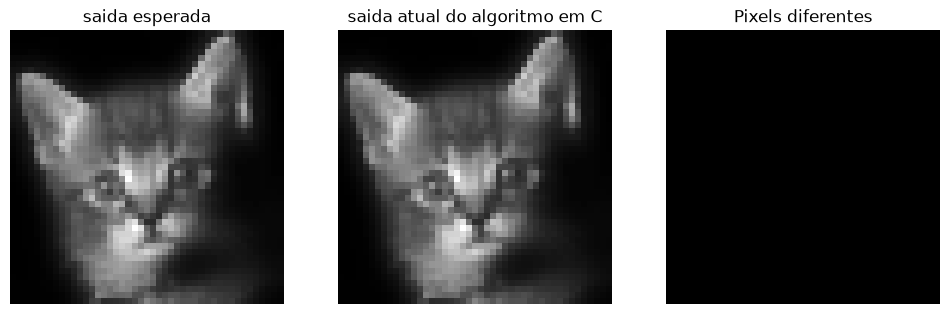

In [3]:
for filename in os.listdir("images_pgm_c_filtradas_com_reflect"):
    if filename.endswith(".pgm"):
        output_actual = cv2.imread(os.path.join("images_pgm_c_filtradas_com_reflect", filename), cv2.IMREAD_GRAYSCALE)
        output_expected = cv2.imread(os.path.join("images_pgm_py_filtradas", filename), cv2.IMREAD_GRAYSCALE)

        if output_expected.shape != output_actual.shape:
            print(f"{filename}: Diferentes: dimensões distintas")
        elif output_expected.dtype != output_actual.dtype:
            print(f"{filename}: Diferentes: tipos de dado distintos (ex.: 8 vs 16 bits)")
        elif np.array_equal(output_expected, output_actual):
            print(f"{filename}: As imagens são idênticas pixel a pixel")
            mask = output_expected != output_actual
            n_diff = mask.sum()
            print(f"{filename}: Diferentes: {n_diff} pixels ({100 * n_diff / mask.size:.4f}% do total)")

            # diferença absoluta em tipo maior, para evitar overflow do uint8
            diff = np.abs(output_expected.astype(np.int32) - output_actual.astype(np.int32))
            print(f"{filename}: Maior diferença:", diff.max())

            coords = np.argwhere(mask)
            print(f"{filename}: Primeiros pixels diferentes (linha, coluna):")
            print(coords[:10])

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(output_expected, cmap="gray"); axes[0].set_title("saida esperada")
        axes[1].imshow(output_actual, cmap="gray"); axes[1].set_title("saida atual do algoritmo em C")
        axes[2].imshow(mask, cmap="gray"); axes[2].set_title("Pixels diferentes")
        for ax in axes:
            ax.axis("off")
        plt.show()

# output_actual = cv2.imread("images_pgm_c_filtradas/resultado01.pgm", cv2.IMREAD_GRAYSCALE)
# output_actual = cv2.imread("images_pgm_c_filtradas/resultado01.pgm", cv2.IMREAD_GRAYSCALE)

# output_expected = cv2.imread("images_pgm_py_filtradas/resultado01.pgm", cv2.IMREAD_GRAYSCALE)

# if output_expected.shape != output_actual.shape:
#     print("Diferentes: dimensões distintas")
# elif output_expected.dtype != output_actual.dtype:
#     print("Diferentes: tipos de dado distintos (ex.: 8 vs 16 bits)")
# elif np.array_equal(output_expected, output_actual):
#     print("As imagens são idênticas pixel a pixel")
# else:
#     mask = output_expected != output_actual
#     n_diff = mask.sum()
#     print(f"Diferentes: {n_diff} pixels ({100 * n_diff / mask.size:.4f}% do total)")

#     # diferença absoluta em tipo maior, para evitar overflow do uint8
#     diff = np.abs(output_expected.astype(np.int32) - output_actual.astype(np.int32))
#     print("Maior diferença:", diff.max())

#     coords = np.argwhere(mask)
#     print("Primeiros pixels diferentes (linha, coluna):")
#     print(coords[:10])


# fig, axs = plt.subplots(1, 3, figsize=(12, 4))
# axs[0].imshow(output_expected, cmap="gray"); axs[0].set_title("saida esperada")
# axs[1].imshow(output_actual, cmap="gray"); axs[1].set_title("saida atual do algoritmo em C")
# axs[2].imshow(mask, cmap="gray"); axs[2].set_title("Pixels diferentes")
# for ax in axs:
#     ax.axis("off")
# plt.show()